# Mall Customer Segmentation using K-Means Clustering

## Project Information

**Dataset:** Mall Customer Segmentation Dataset

**Author:** Muhammad Anas

**Project Type:** Unsupervised Machine Learning

**Algorithm:** K-Means Clustering

**Objective:**
The goal of this project is to segment mall customers into different groups based on their annual income and spending behavior. K-Means clustering will be used to identify similar customer groups, helping businesses better understand customer patterns and make data-driven decisions.

---



## Learning Objectives

By completing this project, I will learn:

- What is Unsupervised Learning
- What is Clustering
- How K-Means Clustering works
- What are Centroids
- What is Inertia (WCSS)
- How to use the Elbow Method
- How to use the Silhouette Score
- How to visualize clusters
- How to interpret clustering results
- How clustering is used in real-world business problems

---

## Tools and Technologies

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-Learn

---

## Expected Outcome

At the end of this project, customers will be grouped into different clusters based on their income and spending patterns. These clusters can be used to understand customer behavior, improve marketing strategies, and support business decision-making.

## Importing Important Libraries


In [1]:
#importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

## Loading the Dataset

In [2]:
#loading the dataset
df=pd.read_csv('D:\\DATA_SCIENCE_PROJECTS\\Ml_Algorathims\\Unsupervised_Machine_Learning\\Dataset\\Mall_Customers.csv')
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [3]:
#renaming the Anuual Income and the Spending Score columns
df.rename(columns={
    'Annual Income (k$)': 'Annual_Income',
    'Spending Score (1-100)': 'Spending_Score'
}, inplace=True)

df.head()

,CustomerID,Gender,Age,Annual_Income,Spending_Score
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


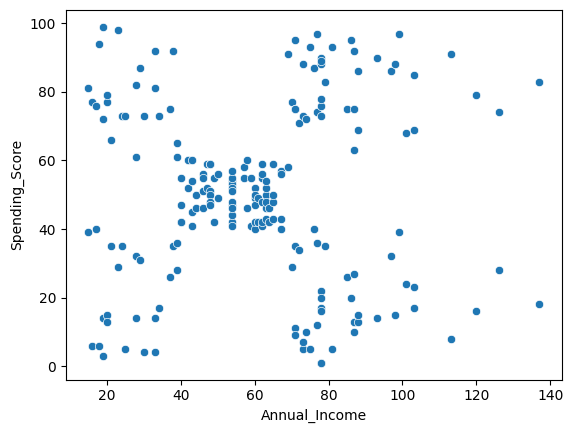

In [4]:
#visualizing the raw data
sns.scatterplot(x='Annual_Income', y='Spending_Score',data=df)
plt.show()

## Finding the Optimal Number of Clusters by the Elbow Method

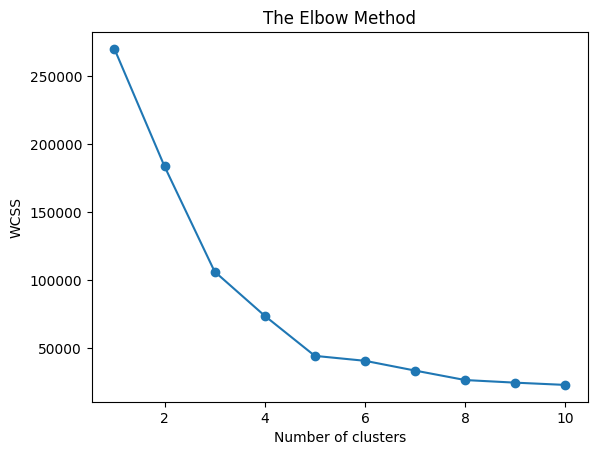

In [5]:
#using the elbow method to find the optimal number of clusters
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i,random_state=42)
    kmeans.fit(df[['Annual_Income', 'Spending_Score']])
    wcss.append(kmeans.inertia_)
    
plt.plot(range(1, 11), wcss,marker='o')
plt.title('The Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

## Verfying the Optimal Number of Clusters by the Silhouette Score

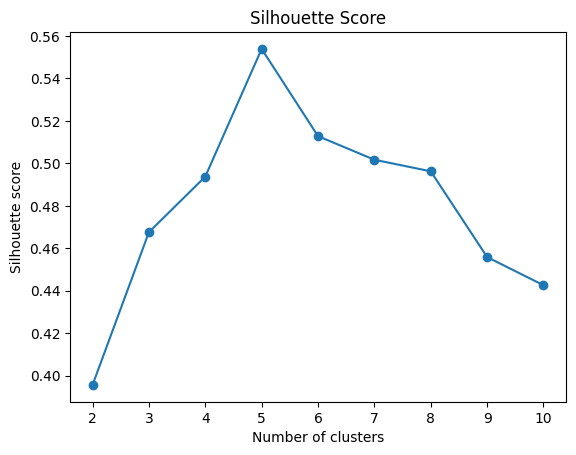

In [6]:
#verfying the optimal number of clusters using the silhouette method

silhouette_scores = []
for i in range(2, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(df[['Annual_Income', 'Spending_Score']])
    labels = kmeans.labels_
    silhouette_scores.append(silhouette_score(df[['Annual_Income', 'Spending_Score']], labels))

plt.plot(range(2, 11), silhouette_scores, marker='o')
plt.title('Silhouette Score')
plt.xlabel('Number of clusters')
plt.ylabel('Silhouette score')
plt.show()

In [7]:
#Applying k-means clustering
kmeans = KMeans(
    n_clusters=5,
    random_state=42
)

clusters = kmeans.fit_predict(df[['Annual_Income', 'Spending_Score']])

df['Cluster'] = clusters


In [8]:
#view the clustered data
df.head()

,CustomerID,Gender,Age,Annual_Income,Spending_Score,Cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4


In [9]:
#view the centroids
print(kmeans.cluster_centers_)

[[55.2962963  49.51851852]
 [86.53846154 82.12820513]
 [25.72727273 79.36363636]
 [88.2        17.11428571]
 [26.30434783 20.91304348]]


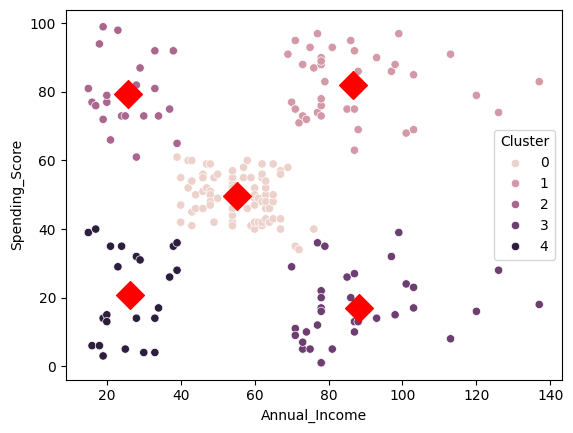

In [10]:
#visualizing the clusters by viewing the centriods and the data points with different colors
sns.scatterplot(x='Annual_Income', y='Spending_Score', hue='Cluster', data=df)
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], s=200, marker='D', c='red')
plt.show()
